# ConVAT

In [ ]:
import pandas as pd
import random
import torch
from torch.utils.data import Dataset
import pytorch_lightning as pl
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import os
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import math

In [2]:
def visualize_cnn_results(
    model_dir,
    class_names=("tidak", "anxiety")
):
    model_dir = model_dir.rstrip("/")

    cm_files = {
        "External": os.path.join(model_dir, "cm_external.png"),
        "Internal": os.path.join(model_dir, "cm_internal.png"),
    }

    report_files = {
        "External": os.path.join(model_dir, "report_external.csv"),
        "Internal": os.path.join(model_dir, "report_internal.csv"),
    }

    # ===== SHOW CONFUSION MATRICES =====
    for name, path in cm_files.items():
        if not os.path.exists(path):
            print(f"❌ Missing {path}")
            continue

        img = mpimg.imread(path)
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"CNN {name} Confusion Matrix")
        plt.show()

    # ===== PRINT CLASSIFICATION REPORTS =====
    for name, path in report_files.items():
        if not os.path.exists(path):
            print(f"❌ Missing {path}")
            continue

        df = pd.read_csv(path, index_col=0)

        print(f"\n=== {name.upper()} CLASSIFICATION REPORT (PERCENT) ===")
        print(f"{'Class':12s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'Support':>9s}")

        for i, cls in enumerate(class_names):
            p, r, f, s = df.loc[str(i), ["precision", "recall", "f1-score", "support"]]
            print(f"{cls:12s} {p*100:9.2f}% {r*100:9.2f}% {f*100:9.2f}% {int(s):9d}")

        acc = df.loc["accuracy", "precision"]
        print(f"Accuracy: {acc*100:.2f}%")

In [3]:
def prepare_balanced_subject_data_from_csv(
    csv_anxiety,
    csv_tidak,
    n_external=2,
    seed=42,
):
    random.seed(seed)

    df_a = pd.read_csv(csv_anxiety)
    df_t = pd.read_csv(csv_tidak)

    subj_a = sorted(df_a["subject"].unique())
    subj_t = sorted(df_t["subject"].unique())

    # =============================
    # BALANCE SUBJECT COUNT
    # =============================
    n_min = min(len(subj_a), len(subj_t))

    subj_a = random.sample(subj_a, n_min)
    subj_t = random.sample(subj_t, n_min)

    # =============================
    # EXTERNAL SUBJECTS
    # =============================
    ext_a = subj_a[:n_external]
    ext_t = subj_t[:n_external]

    train_a = subj_a[n_external:]
    train_t = subj_t[n_external:]

    df_train = pd.concat([
        df_a[df_a["subject"].isin(train_a)],
        df_t[df_t["subject"].isin(train_t)],
    ], ignore_index=True)

    df_external = pd.concat([
        df_a[df_a["subject"].isin(ext_a)],
        df_t[df_t["subject"].isin(ext_t)],
    ], ignore_index=True)

    print("📊 SUBJECT STATS:", {
        "balanced_per_class": n_min,
        "train_per_class": len(train_a),
        "external_per_class": n_external,
    })

    return df_train.reset_index(drop=True), df_external.reset_index(drop=True)

In [4]:
def save_confusion_matrix(cm, labels, out_path, title):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=labels,
                yticklabels=labels,
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()

In [5]:
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, average=None
    )

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "support": sup,
        "cm": confusion_matrix(y_true, y_pred),
        "report": classification_report(y_true, y_pred, output_dict=True)
    }

In [16]:
class TabularDataset(Dataset):
    def __init__(self, df, feature_cols):
        self.X = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.y = torch.tensor(
            (df["label"] == "anxiety").astype(int).values,
            dtype=torch.long
        )

        n_feat = self.X.shape[1]
        H = int(math.sqrt(n_feat))
        W = math.ceil(n_feat / H)

        self.H = H
        self.W = W
        self.target_size = H * W

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]

        if x.numel() < self.target_size:
            x = F.pad(x, (0, self.target_size - x.numel()))
        else:
            x = x[:self.target_size]

        x = x.view(1, self.H, self.W)
        y = self.y[idx]
        return x, y


In [20]:
class ConVAT(pl.LightningModule):
    def __init__(self, in_channels=1, num_classes=2, lr=1e-3):
        super().__init__()
        self.lr = lr

        # ===== ENCODER =====
        self.enc1 = self.conv_block(in_channels, 32, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = self.conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # ===== BOTTLENECK + ATTENTION =====
        self.bottleneck_conv = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)

        self.attention = nn.MultiheadAttention(
            embed_dim=256,
            num_heads=8,
            batch_first=True
        )
        self.squeeze = nn.AdaptiveAvgPool2d(1)

        # ===== DECODER =====
        self.upconv1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(256, 128, 64)

        self.upconv2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(96, 64, 32)

        # ===== CLASSIFICATION HEAD =====
        self.fc1 = nn.Linear(256, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.drop1 = nn.Dropout(0.5)

        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.drop2 = nn.Dropout(0.5)

        self.fc_out = nn.Linear(512, num_classes)

        # ===== SEGMENTATION HEAD =====
        self.final_conv = nn.Conv2d(32, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

        self.criterion = nn.CrossEntropyLoss()

    def conv_block(self, in_channels, *filters):
        layers = []
        c = in_channels
        for f in filters:
            layers.append(nn.Conv2d(c, f, kernel_size=3, padding=1))
            layers.append(nn.ReLU(inplace=True))
            c = f
        return nn.Sequential(*layers)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.relu(self.bottleneck_conv(p2))
        B, C, H, W = b.shape

        t = b.view(B, C, H * W).permute(0, 2, 1)
        a, _ = self.attention(t, t, t)
        a = a.permute(0, 2, 1).view(B, C, H, W)

        s = self.squeeze(a).view(B, -1)

        x = self.drop1(self.bn1(self.relu(self.fc1(s))))
        x = self.drop2(self.bn2(self.relu(self.fc2(x))))
        class_out = self.fc_out(x)

        u1 = self.upconv1(a)
        e2c = self.center_crop(e2, u1)
        d1 = self.dec1(torch.cat([u1, e2c], dim=1))


        u2 = self.upconv2(d1)
        e1c = self.center_crop(e1, u2)
        d2 = self.dec2(torch.cat([u2, e1c], dim=1))


        _ = self.sigmoid(self.final_conv(d2))

        return class_out

    def center_crop(self, src, target):
        _, _, h, w = src.shape
        _, _, ht, wt = target.shape

        dh = (h - ht) // 2
        dw = (w - wt) // 2

        return src[:, :, dh:dh+ht, dw:dw+wt]

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        acc = (y_hat.argmax(dim=1) == y).float().mean()
        self.log_dict({"val_loss": loss, "val_acc": acc})

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


In [13]:
def train_cnn_group(
    csv_anxiety,
    csv_tidak,
    out_dir,
    n_external=2,
    batch_size=64,
    max_epochs=50,
):
    os.makedirs(out_dir, exist_ok=True)

    df_train, df_external = prepare_balanced_subject_data_from_csv(
        csv_anxiety, csv_tidak, n_external=n_external
    )

    drop_cols = ["label", "condition", "subject", "question", "device", "frame"]
    feature_cols = [c for c in df_train.columns if c not in drop_cols]

    imputer = SimpleImputer(strategy="mean")
    scaler = StandardScaler()

    df_train[feature_cols] = scaler.fit_transform(
        imputer.fit_transform(df_train[feature_cols])
    )
    df_external[feature_cols] = scaler.transform(
        imputer.transform(df_external[feature_cols])
    )

    df_tr, df_val = train_test_split(
        df_train,
        test_size=0.2,
        stratify=df_train["label"],
        random_state=42
    )

    train_ds = TabularDataset(df_tr, feature_cols)
    val_ds   = TabularDataset(df_val, feature_cols)
    ext_ds   = TabularDataset(df_external, feature_cols)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size)
    ext_loader   = DataLoader(ext_ds, batch_size=batch_size)

    model = ConVAT(num_classes=2)

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator="gpu",
        log_every_n_steps=10,
        default_root_dir=out_dir
    )

    trainer.fit(model, train_loader, val_loader)

    print("🔎 INTERNAL (Validation)")
    res_int = evaluate_model(model, val_loader)

    print("🔎 EXTERNAL (Subject Holdout)")
    res_ext = evaluate_model(model, ext_loader)

    save_confusion_matrix(
        res_int["cm"],
        ["tidak", "anxiety"],
        os.path.join(out_dir, "cm_internal.png"),
        "ConVAT Internal Confusion Matrix"
    )

    save_confusion_matrix(
        res_ext["cm"],
        ["tidak", "anxiety"],
        os.path.join(out_dir, "cm_external.png"),
        "ConVAT External Confusion Matrix"
    )

    pd.DataFrame(res_int["report"]).transpose().to_csv(
        os.path.join(out_dir, "report_internal.csv")
    )
    pd.DataFrame(res_ext["report"]).transpose().to_csv(
        os.path.join(out_dir, "report_external.csv")
    )

    trainer.save_checkpoint(os.path.join(out_dir, "convat_model.ckpt"))

In [14]:
torch.set_float32_matmul_precision('medium')

## Before After

### Before Flatten

In [21]:
train_cnn_group(
    csv_anxiety="../features_grouped/flatten/before_anxiety.csv",
    csv_tidak="../features_grouped/flatten/before_tidak.csv",
    out_dir="models/conVAT_before/flatten_balanced/",
    n_external=2
)

📊 SUBJECT STATS: {'balanced_per_class': 24, 'train_per_class': 22, 'external_per_class': 2}


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name            | Type               | Params | Mode  | FLOPs
------------------------------------------------------------------------
0  | enc1            | Sequential         | 18.8 K | train | 0    
1  | pool1           | MaxPool2d          | 0      | train | 0    
2  | enc2            | Sequential         | 73.9 K | train | 0    
3  | pool2           | MaxPool2d          | 0      | train | 0    
4  | bottleneck_conv | Conv2d             | 295 K  | train | 0    
5  | relu            | ReLU               | 0      | train | 0    
6  | attention       | MultiheadAttention | 263 K  | train | 0    
7  | squeeze         | AdaptiveAvgPool2d  | 0      | train | 0 

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 49: 100%|██████████| 1442/1442 [00:13<00:00, 110.17it/s, v_num=2]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 1442/1442 [00:13<00:00, 109.74it/s, v_num=2]
🔎 INTERNAL (Validation)
🔎 EXTERNAL (Subject Holdout)


`weights_only` was not set, defaulting to `False`.


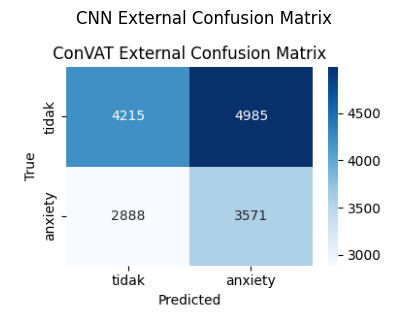

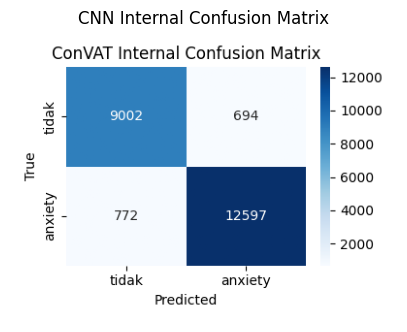


=== EXTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            59.34%     45.82%     51.71%      9200
anxiety          41.74%     55.29%     47.57%      6459
Accuracy: 49.72%

=== INTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            92.10%     92.84%     92.47%      9696
anxiety          94.78%     94.23%     94.50%     13369
Accuracy: 93.64%


In [23]:
visualize_cnn_results(
    "models/conVAT_before/flatten_balanced/"
)